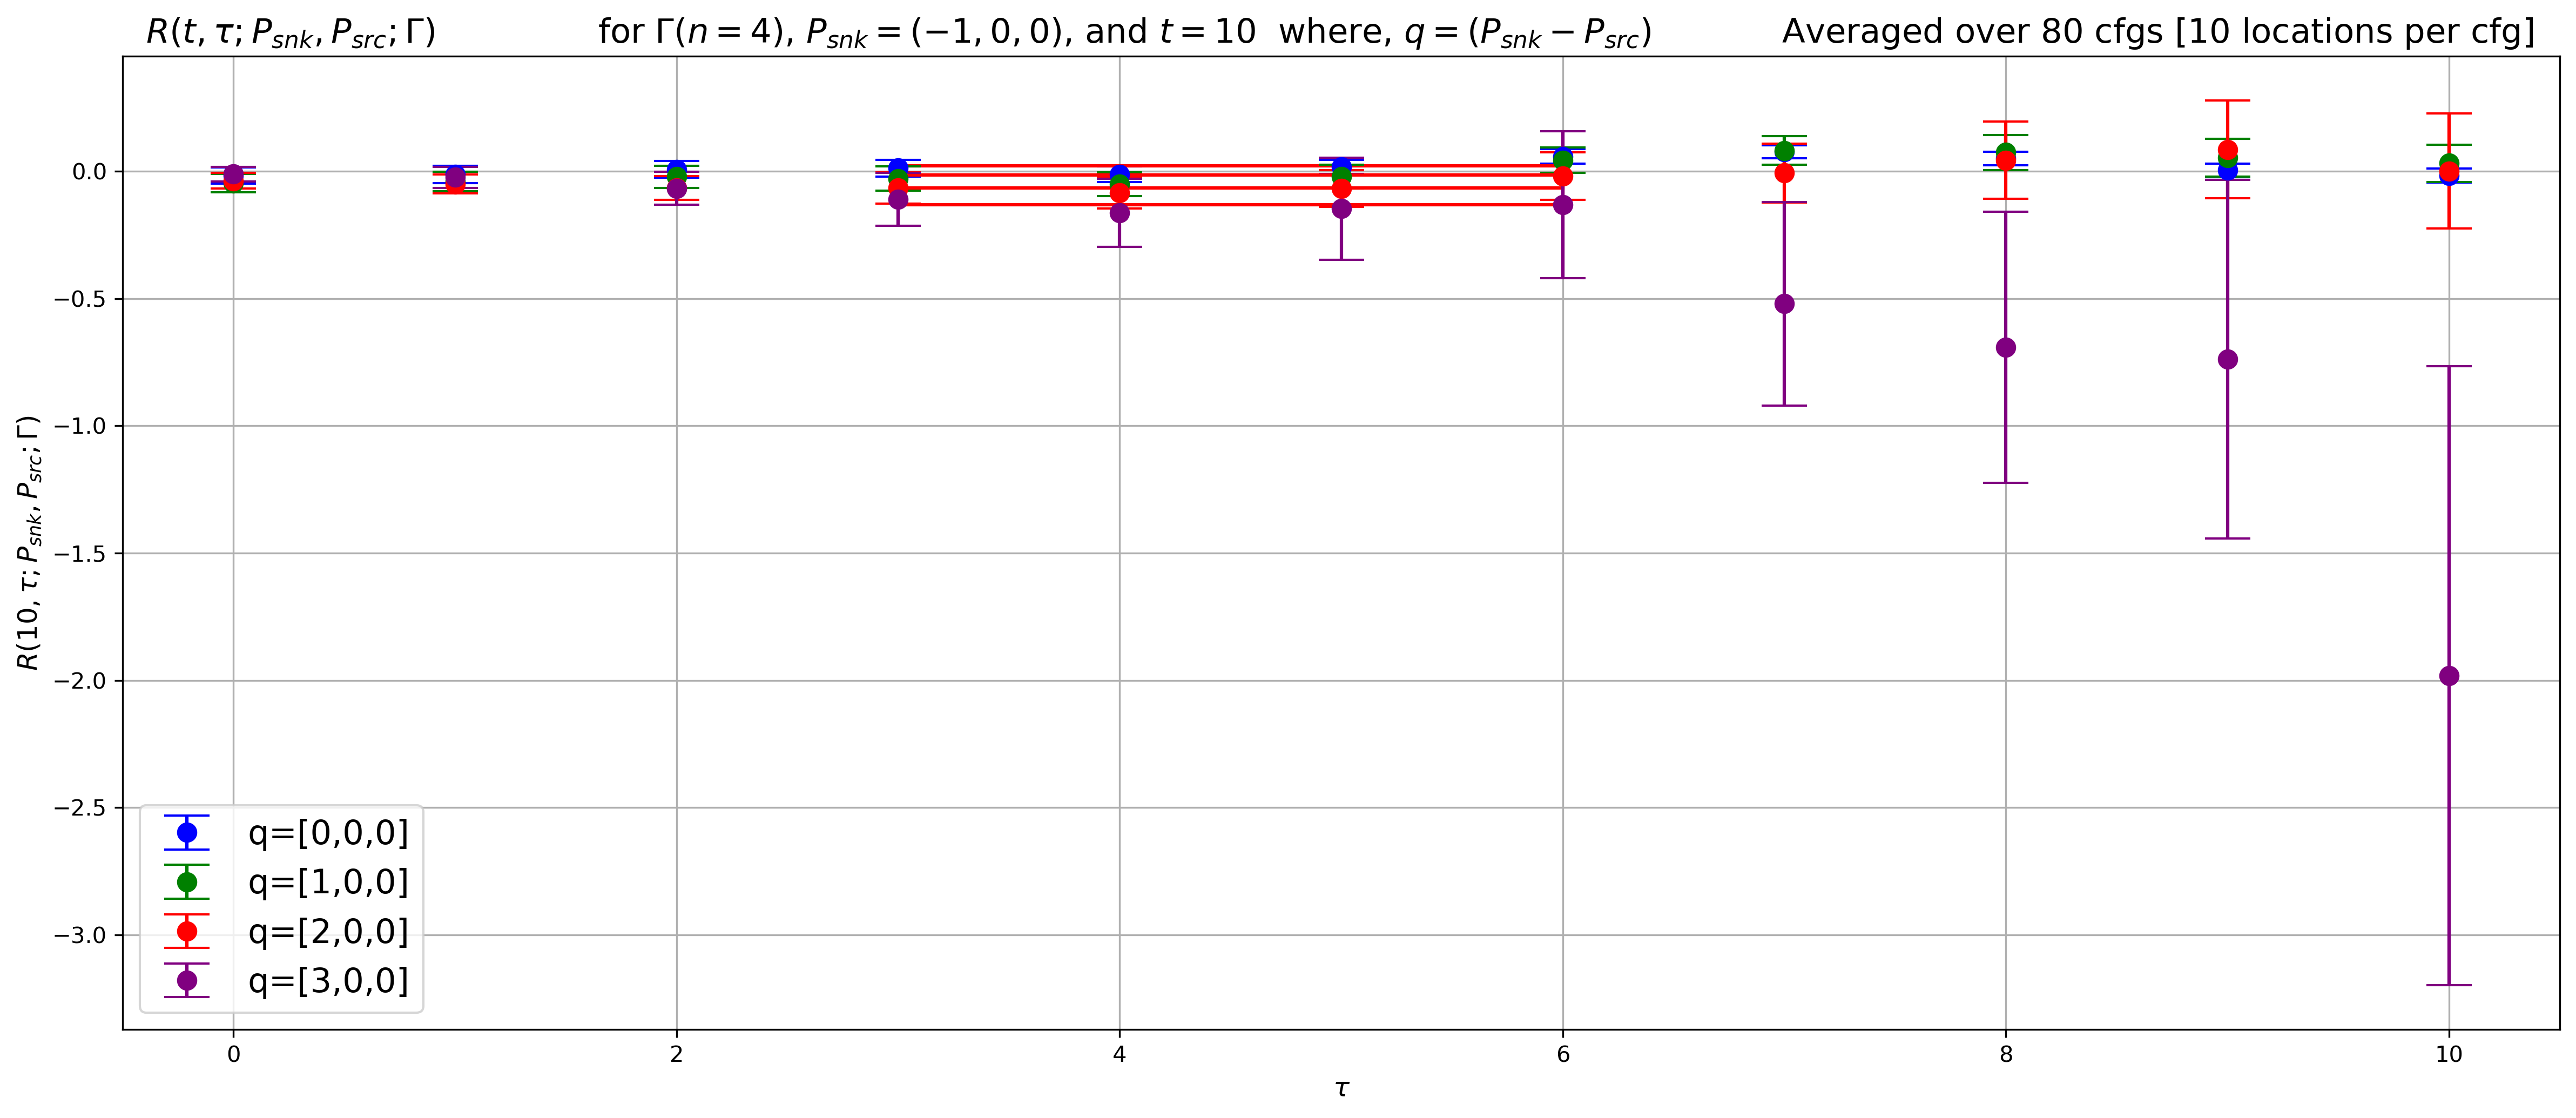

        
[0.021498810267970837, -0.015040085172159988, -0.06520542308118774, -0.13173330798443292]


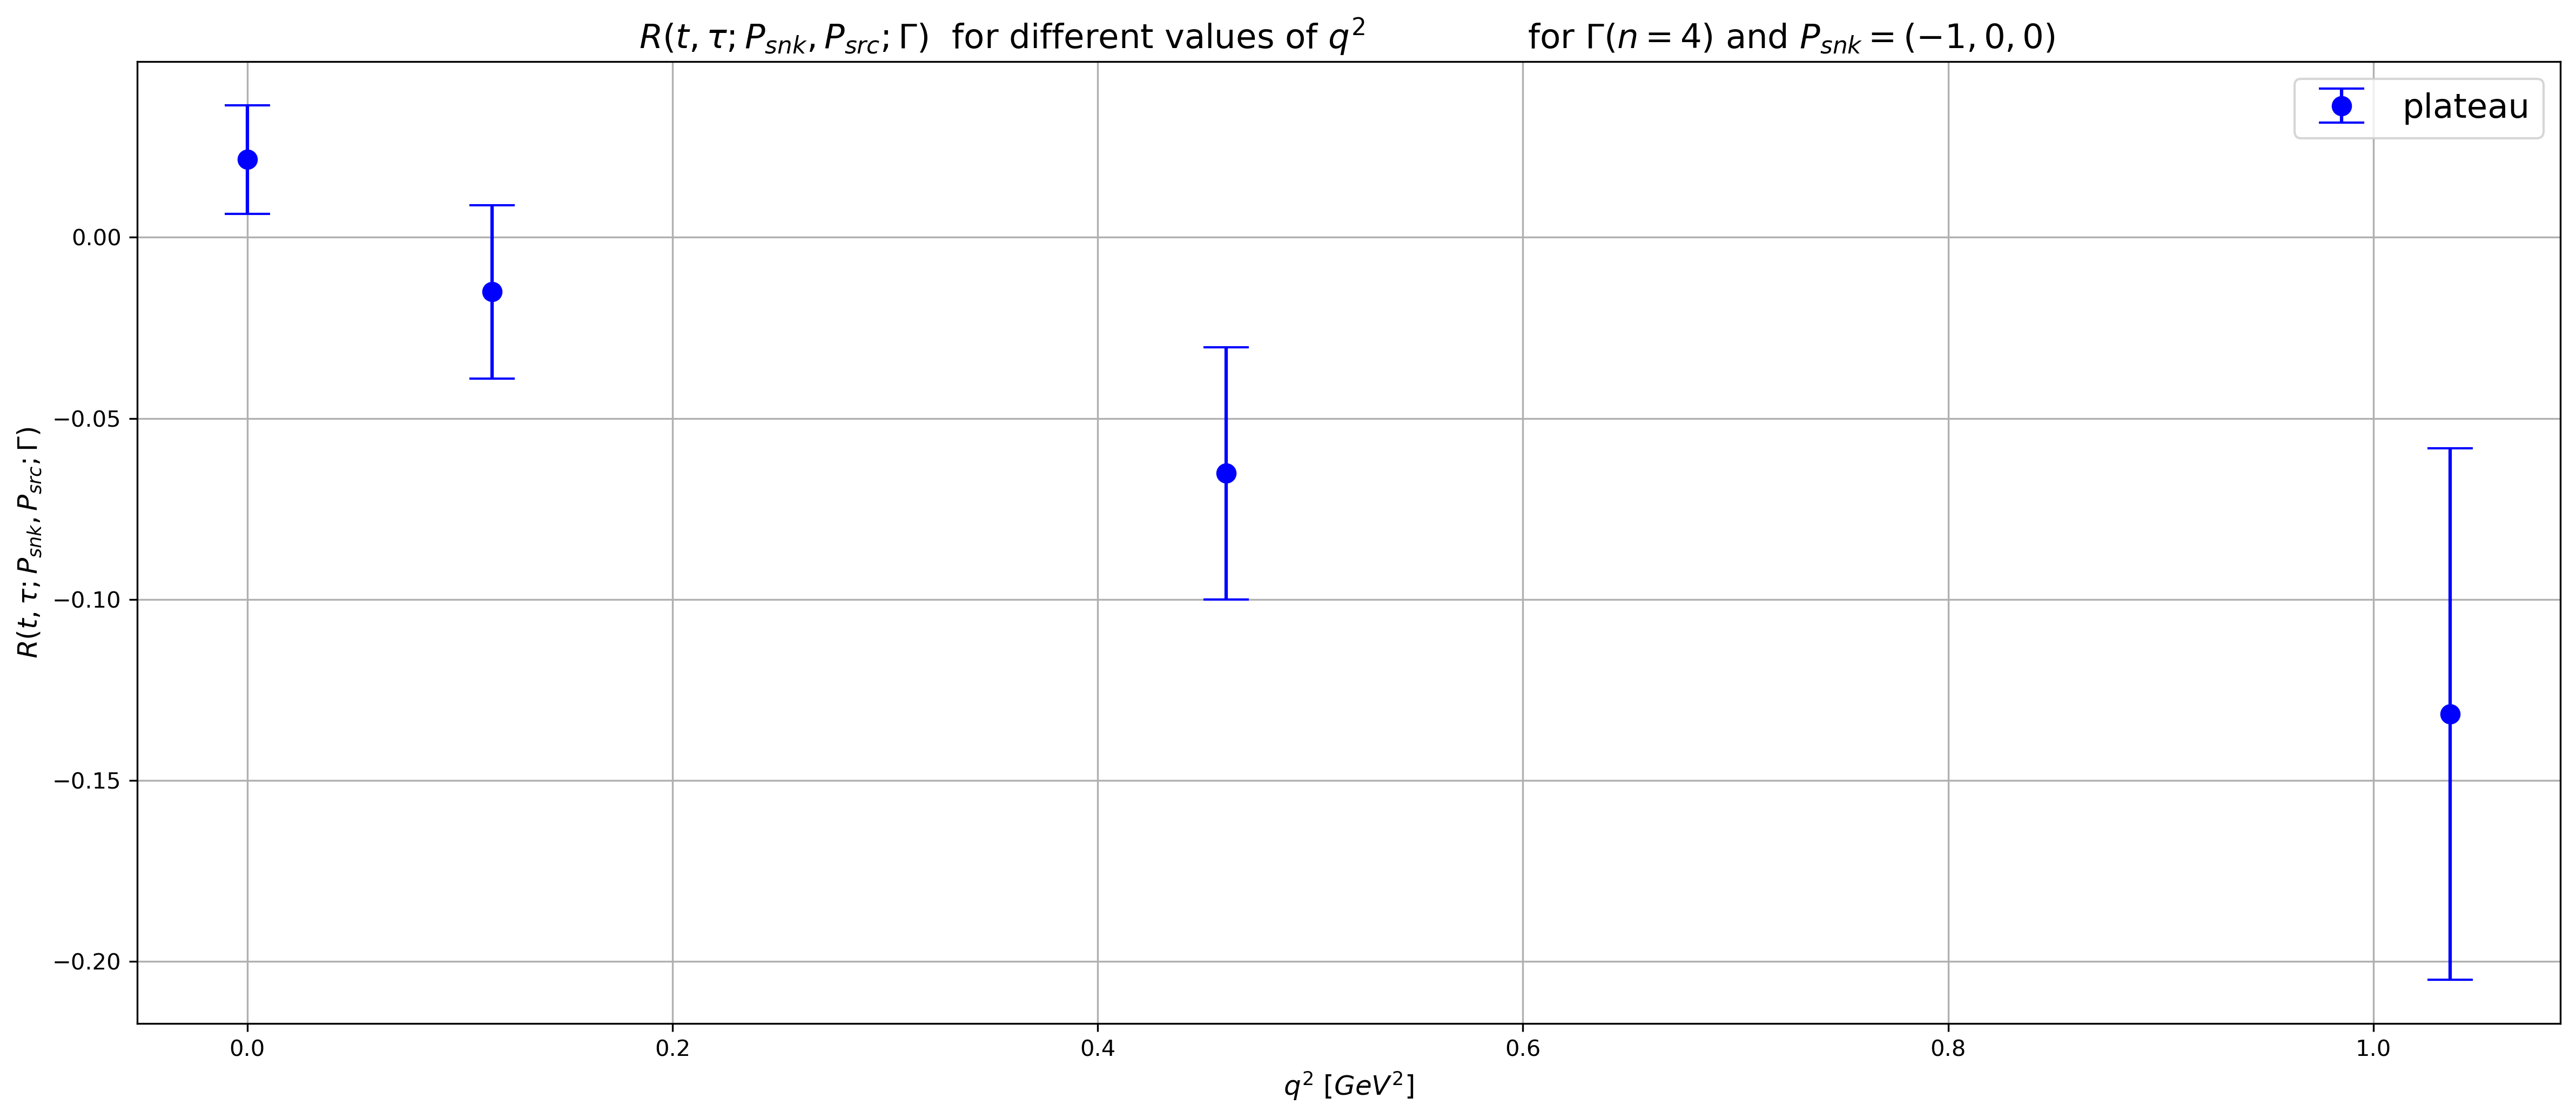

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from contextlib import ExitStack

#lattice size a
a = 0.114

# plateau_fit
def plateau_fit(x, y):
    return y*(x/x)

file_path_RN = "/pscratch/sd/h/hari_8/saved_prop_files/save_3pt_2pt/save_3pt_2pt_cfgs_psnk_m1_0_0_0_cfg_1776_2092_.h5"
file_path_RA = "/pscratch/sd/h/hari_8/saved_prop_files/save_3pt_2pt/save_3pt_2pt_cfgs_psnk_m1_0_0_0_cfg_1776_2092_.h5"

sources = [[0, 0, 0, 0], [8, 0, 0, 0], [16, 0, 0, 0], [24, 0, 0, 0], [0, 8, 0, 0], [0, 16, 0, 0], [0, 24, 0, 0], [0, 0, 8, 0], [0, 0, 16, 0], [0, 0, 24, 0]]
psnk = [-1,0,0,0]
t = 10
tsnk = 10

def extract_3pt_2pt_cfg_list(tau, q, g):
    psrc = [(psnk[0] - q[0]), (psnk[1] - q[1]), (psnk[2] - q[2]), (psnk[3] - q[3])]
    with ExitStack() as stack:
        h5_file_RN = stack.enter_context(h5py.File(file_path_RN, "r"))
        h5_file_RA = stack.enter_context(h5py.File(file_path_RA, "r"))
        no_cfgs = 0
        list_cfg_G3_U = []
        list_cfg_G3_D = []
        list_cfg_G2_t_psnk = []
        list_cfg_G2_tau_psnk = []
        list_cfg_G2_t_tau_psrc = []
        list_cfg_G2_tau_psrc = []
        list_cfg_G2_t_psrc = []
        list_cfg_G2_t_tau_psnk = []
        for cfg in range(1776, 2093, 4): #1984 #2092
            no_cfgs = no_cfgs + 1
            per_src_G3_U = []
            per_src_G3_D = []
            per_src_G2_t_psnk = []
            per_src_G2_tau_psnk = []
            per_src_G2_t_tau_psrc = []
            per_src_G2_tau_psrc = []
            per_src_G2_t_psrc = []
            per_src_G2_t_tau_psnk = []
            for csrc in sources:
                # 3pt U quark
                path_to_G3_U_vector = f"/cfg_{cfg}/ThreePT_flavor_U/x{csrc[0]}_y{csrc[1]}_z{csrc[2]}_t{csrc[3]}/PX{psnk[0]}_PY{psnk[1]}_PZ{psnk[2]}_T{t}/g{g}/qx{q[0]}_qy{q[1]}_qz{q[2]}"
                c_array_G3_U = h5_file_RN[path_to_G3_U_vector]
                real_array_G3_U = (c_array_G3_U[()]).imag
                per_src_G3_U.append(real_array_G3_U[tau])
                
                # 3pt D quark
                path_to_G3_D_vector = f"/cfg_{cfg}/ThreePT_flavor_D/x{csrc[0]}_y{csrc[1]}_z{csrc[2]}_t{csrc[3]}/PX{psnk[0]}_PY{psnk[1]}_PZ{psnk[2]}_T{t}/g{g}/qx{q[0]}_qy{q[1]}_qz{q[2]}"
                c_array_G3_D = h5_file_RN[path_to_G3_D_vector]
                real_array_G3_D = (c_array_G3_D[()]).imag
                per_src_G3_D.append(real_array_G3_D[tau])
                
                # 2pt G2(t,psnk)
                path_to_G2_t_psnk_c_vector = f"/cfg_{cfg}/TwoPT_proton3/x{csrc[0]}_y{csrc[1]}_z{csrc[2]}_t{csrc[3]}/PX{psnk[0]}_PY{psnk[1]}_PZ{psnk[2]}_T{t}"
                c_array_G2_t_psnk = h5_file_RN[path_to_G2_t_psnk_c_vector]
                real_array_G2_t_psnk = (c_array_G2_t_psnk[()]).real
                per_src_G2_t_psnk.append(real_array_G2_t_psnk[t])
                
                # 2pt G2(tau,psnk)
                path_to_G2_tau_psnk_c_vector = f"/cfg_{cfg}/TwoPT_proton3/x{csrc[0]}_y{csrc[1]}_z{csrc[2]}_t{csrc[3]}/PX{psnk[0]}_PY{psnk[1]}_PZ{psnk[2]}_T{t}"
                c_array_G2_tau_psnk = h5_file_RN[path_to_G2_tau_psnk_c_vector]
                real_array_G2_tau_psnk = (c_array_G2_tau_psnk[()]).real
                per_src_G2_tau_psnk.append(real_array_G2_tau_psnk[tau])
                
                # 2pt G2(t-tau,psrc)
                path_to_G2_t_tau_psrc_c_vector = f"/cfg_{cfg}/TwoPT_proton3/x{csrc[0]}_y{csrc[1]}_z{csrc[2]}_t{csrc[3]}/PX{psrc[0]}_PY{psrc[1]}_PZ{psrc[2]}_T{t}"
                c_array_G2_t_tau_psrc = h5_file_RA[path_to_G2_t_tau_psrc_c_vector]
                real_array_G2_t_tau_psrc = (c_array_G2_t_tau_psrc[()]).real
                per_src_G2_t_tau_psrc.append(real_array_G2_t_tau_psrc[t-tau])
                
                # 2pt G2(tau,psrc)
                path_to_G2_tau_psrc_c_vector = f"/cfg_{cfg}/TwoPT_proton3/x{csrc[0]}_y{csrc[1]}_z{csrc[2]}_t{csrc[3]}/PX{psrc[0]}_PY{psrc[1]}_PZ{psrc[2]}_T{t}"
                c_array_G2_tau_psrc = h5_file_RA[path_to_G2_tau_psrc_c_vector]
                real_array_G2_tau_psrc = (c_array_G2_tau_psrc[()]).real
                per_src_G2_tau_psrc.append(real_array_G2_tau_psrc[tau])
                
                # 2pt G2(t,psrc)
                path_to_G2_t_psrc_c_vector = f"/cfg_{cfg}/TwoPT_proton3/x{csrc[0]}_y{csrc[1]}_z{csrc[2]}_t{csrc[3]}/PX{psrc[0]}_PY{psrc[1]}_PZ{psrc[2]}_T{t}"
                c_array_G2_t_psrc = h5_file_RA[path_to_G2_t_psrc_c_vector]
                real_array_G2_t_psrc = (c_array_G2_t_psrc[()]).real
                per_src_G2_t_psrc.append(real_array_G2_t_psrc[t])
                
                # 2pt G2(t-tau,psnk)
                path_to_G2_t_tau_psnk_c_vector = f"/cfg_{cfg}/TwoPT_proton3/x{csrc[0]}_y{csrc[1]}_z{csrc[2]}_t{csrc[3]}/PX{psnk[0]}_PY{psnk[1]}_PZ{psnk[2]}_T{t}"
                c_array_G2_t_tau_psnk = h5_file_RN[path_to_G2_t_tau_psnk_c_vector]
                real_array_G2_t_tau_psnk = (c_array_G2_t_tau_psnk[()]).real
                per_src_G2_t_tau_psnk.append(real_array_G2_t_tau_psnk[t-tau])
                
            list_cfg_G3_U.append(np.mean(per_src_G3_U))
            list_cfg_G3_D.append(np.mean(per_src_G3_D))
            list_cfg_G2_t_psnk.append(np.mean(per_src_G2_t_psnk))
            list_cfg_G2_tau_psnk.append(np.mean(per_src_G2_tau_psnk))
            list_cfg_G2_t_tau_psrc.append(np.mean(per_src_G2_t_tau_psrc))
            list_cfg_G2_tau_psrc.append(np.mean(per_src_G2_tau_psrc))
            list_cfg_G2_t_psrc.append(np.mean(per_src_G2_t_psrc))
            list_cfg_G2_t_tau_psnk.append(np.mean(per_src_G2_t_tau_psnk))
    return list_cfg_G3_U, list_cfg_G3_D, list_cfg_G2_t_psnk, list_cfg_G2_tau_psnk, list_cfg_G2_t_tau_psrc, list_cfg_G2_tau_psrc, list_cfg_G2_t_psrc, list_cfg_G2_t_tau_psnk, no_cfgs

def jackknife_ratio_for_tau(tau, q, g):
    list_cfg_G3_U, list_cfg_G3_D, list_cfg_G2_t_psnk, list_cfg_G2_tau_psnk, list_cfg_G2_t_tau_psrc, list_cfg_G2_tau_psrc, list_cfg_G2_t_psrc, list_cfg_G2_t_tau_psnk, no_cfgs = extract_3pt_2pt_cfg_list(tau, q, g)
    G3_U = np.mean(list_cfg_G3_U)
    G3_D = np.mean(list_cfg_G3_D)
    G2_t_psnk = np.mean(list_cfg_G2_t_psnk)
    G2_tau_psnk = np.mean(list_cfg_G2_tau_psnk)
    G2_t_tau_psrc = np.mean(list_cfg_G2_t_tau_psrc)
    G2_tau_psrc = np.mean(list_cfg_G2_tau_psrc)
    G2_t_psrc = np.mean(list_cfg_G2_t_psrc)
    G2_t_tau_psnk = np.mean(list_cfg_G2_t_tau_psnk)
    Ratio = ((G3_U-G3_D)/G2_t_psnk)*np.sqrt((G2_tau_psnk*G2_t_psnk*G2_t_tau_psrc)/(G2_tau_psrc*G2_t_psrc*G2_t_tau_psnk))
    # making jackknife set
    sigma_square_Ratio = 0
    for i in range(len(list_cfg_G3_U)): #Jackknife
        sliced_list_cfg_G3_U = list_cfg_G3_U[:(i)] + list_cfg_G3_U[(i+1):]
        sliced_list_cfg_G3_D = list_cfg_G3_D[:(i)] + list_cfg_G3_D[(i+1):]
        sliced_list_cfg_G2_t_psnk = list_cfg_G2_t_psnk[:(i)] + list_cfg_G2_t_psnk[(i+1):]
        sliced_list_cfg_G2_tau_psnk = list_cfg_G2_tau_psnk[:(i)] + list_cfg_G2_tau_psnk[(i+1):]
        sliced_list_cfg_G2_t_tau_psrc = list_cfg_G2_t_tau_psrc[:(i)] + list_cfg_G2_t_tau_psrc[(i+1):]
        sliced_list_cfg_G2_tau_psrc = list_cfg_G2_tau_psrc[:(i)] + list_cfg_G2_tau_psrc[(i+1):]
        sliced_list_cfg_G2_t_psrc = list_cfg_G2_t_psrc[:(i)] + list_cfg_G2_t_psrc[(i+1):]
        sliced_list_cfg_G2_t_tau_psnk = list_cfg_G2_t_tau_psnk[:(i)] + list_cfg_G2_t_tau_psnk[(i+1):]
        #make averages of 2pts and 3pt for each jackknife set
        jackknife_G3_U = np.mean(sliced_list_cfg_G3_U)
        jackknife_G3_D = np.mean(sliced_list_cfg_G3_D)
        jackknife_G2_t_psnk = np.mean(sliced_list_cfg_G2_t_psnk)
        jackknife_G2_tau_psnk = np.mean(sliced_list_cfg_G2_tau_psnk)
        jackknife_G2_t_tau_psrc = np.mean(sliced_list_cfg_G2_t_tau_psrc)
        jackknife_G2_tau_psrc = np.mean(sliced_list_cfg_G2_tau_psrc)
        jackknife_G2_t_psrc = np.mean(sliced_list_cfg_G2_t_psrc)
        jackknife_G2_t_tau_psnk = np.mean(sliced_list_cfg_G2_t_tau_psnk)
        jackknife_Ratio = ((jackknife_G3_U-jackknife_G3_D)/jackknife_G2_t_psnk)*np.sqrt((jackknife_G2_tau_psnk*jackknife_G2_t_psnk*jackknife_G2_t_tau_psrc)/(jackknife_G2_tau_psrc*jackknife_G2_t_psrc*jackknife_G2_t_tau_psnk))
        sigma_square_Ratio = sigma_square_Ratio + np.square(Ratio-jackknife_Ratio)
    error_Ratio = np.sqrt(((no_cfgs-1)/(no_cfgs))*sigma_square_Ratio)
    return Ratio, error_Ratio, no_cfgs

def ratio_list_tau(q, g, plateau_t_i, plateau_t_f):
    ratio_list = []
    error_ratio_list = []
    for tau in (range(0, tsnk+1)):
        Ratio, error_Ratio, no_cfgs = jackknife_ratio_for_tau(tau, q, g) 
        ratio_list.append(Ratio)
        error_ratio_list.append(error_Ratio)
    ####################### Curve fitting #######################
    time_for_plateau = list(range(plateau_t_i, plateau_t_f + 1))
    ratio_3pt_list_plateau = []
    ratio_3pt_err_list_plateau = []
    for t_plateau in range(len(time_for_plateau)):
        ratio_3pt_list_plateau.append(ratio_list[t_plateau+plateau_t_i])
        ratio_3pt_err_list_plateau.append(error_ratio_list[t_plateau+plateau_t_i])
    params, cov = curve_fit(plateau_fit, time_for_plateau, ratio_3pt_list_plateau, sigma = ratio_3pt_err_list_plateau, absolute_sigma=True)
    ratio_3pt_2pt = params
    ratio_3pt_2pt_err = np.sqrt(np.diag(cov))
    x_curve_plateau = np.linspace(np.min(time_for_plateau), np.max(time_for_plateau), 100)
    y_curve_plateau = np.full(100, ratio_3pt_2pt) 
    return ratio_list, error_ratio_list, x_curve_plateau, y_curve_plateau, ratio_3pt_2pt, ratio_3pt_2pt_err, no_cfgs

def plot_ratio_3pt_2pt(g, q_list, plateau_range):
    plt.subplots(figsize=(16, 7),dpi=300)
    colors = ['blue', 'green', 'red', 'purple', 'magenta' , 'orange', 'cyan', 'yellow']
    for i, q in enumerate(q_list):
        plateau_t_i, plateau_t_f = plateau_range[i]
        time_for_plot = list(range(0, tsnk+1))
        ratio_3pt_original, error_ratio_3pt_jackknife, x_curve_plateau, y_curve_plateau, ratio_3pt_2pt, ratio_3pt_2pt_err, no_cfgs = ratio_list_tau(q, g, plateau_t_i, plateau_t_f)
        #print(ratio_3pt_2pt_err)
        plt.errorbar(time_for_plot, ratio_3pt_original, yerr = error_ratio_3pt_jackknife, fmt='o', markersize=8, capsize=10, color=colors[i], label= 'q=[{},{},{}]'.format(q[0],q[1],q[2]))
        plt.plot(x_curve_plateau, y_curve_plateau, 'r-')
    plt.xlabel("$\\tau$", fontsize=12)
    plt.ylabel("$R(10,\\tau;P_{snk},P_{src};\Gamma)$", fontsize=12)
    plt.title("$R(t,\\tau;P_{snk},P_{src};\Gamma)$               for $\Gamma(n=%d)$, $P_{snk}=(%d,%d,%d)$, and $t=10$  where, $(q=P_{snk}-P_{src})$               Averaged over %d cfgs [%d locations per cfg] "%(g, psnk[0], psnk[1], psnk[2], no_cfgs, len(sources)), fontsize=15)
    plt.legend(fontsize=15)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.grid(True) 
    plt.show()
    return

def plot_ratio_3pt_2pt_q_old(g, q_list, plateau_range):
    plt.subplots(figsize=(16, 7),dpi=300)
    colors = ['blue', 'green', 'red', 'purple', 'magenta', 'orange', 'cyan', 'yellow', 'indigo', 'pink', 'turquoise', 'olive', 'lavender']
    #normalizing with charge
    plateau_t_i_n, plateau_t_f_n = plateau_range[0]
    #nor_ratio_3pt_original, nor_error_ratio_3pt_jackknife, nor_x_curve_plateau, nor_y_curve_plateau, nor_ratio_3pt_2pt, nor_ratio_3pt_2pt_err, nor_no_cfgs = ratio_list_tau([0,0,0,0], g, plateau_t_i_n, plateau_t_f_n)
    list_ratio_3pt_2pt = []
    list_ratio_3pt_2pt_err = []
    list_q_square = []
    for i, q in enumerate(q_list): 
        q_three = np.square((q[0]*2*np.pi*197)/(a*32))+np.square((q[1]*2*np.pi*197)/(a*32))+np.square((q[2]*2*np.pi*197)/(a*32))
        list_q_square.append(q_three/1000000)
        plateau_t_i, plateau_t_f = plateau_range[i]
        time_for_plot = list(range(0, tsnk+1))
        ratio_3pt_original, error_ratio_3pt_jackknife, x_curve_plateau, y_curve_plateau, ratio_3pt_2pt, ratio_3pt_2pt_err, no_cfgs = ratio_list_tau(q, g, plateau_t_i, plateau_t_f)
        #list_ratio_3pt_2pt.append(ratio_3pt_2pt[0])
        #list_ratio_3pt_2pt_err.append(ratio_3pt_2pt_err[0])
        ##
        list_ratio_3pt_2pt.append(((ratio_3pt_2pt[0])))
        list_ratio_3pt_2pt_err.append(ratio_3pt_2pt_err[0])
        ##
        plt.errorbar(time_for_plot, ratio_3pt_original, yerr = error_ratio_3pt_jackknife, fmt='o', markersize=8, capsize=10, color=colors[i], label= 'q=[{},{},{}]'.format(q[0],q[1],q[2]))
        plt.plot(x_curve_plateau, y_curve_plateau, 'r-')
    plt.xlabel("$\\tau$", fontsize=12)
    plt.ylabel("$R(10,\\tau;P_{snk},P_{src};\Gamma)$", fontsize=12)
    plt.title("$R(t,\\tau;P_{snk},P_{src};\Gamma)$               for $\Gamma(n=%d)$, $P_{snk}=(%d,%d,%d)$, and $t=10$  where, $q=(P_{snk}-P_{src})$            Averaged over %d cfgs [%d locations per cfg] "%(g, psnk[0], psnk[1], psnk[2], no_cfgs, len(sources)), fontsize=15)
    plt.legend(fontsize=15)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.grid(True) 
    plt.show()
    print("        ")
    print(list_ratio_3pt_2pt)
    plt.subplots(figsize=(16, 7),dpi=300)
    plt.errorbar(list_q_square, list_ratio_3pt_2pt, yerr = list_ratio_3pt_2pt_err, fmt='o', markersize=8, capsize=10, color='blue', label= "plateau")
    plt.ylabel("$R(t,\\tau;P_{snk},P_{src};\Gamma)$", fontsize=12)
    plt.xlabel("$q^{2}~[GeV^2]$", fontsize=12)
    plt.title("$R(t,\\tau;P_{snk},P_{src};\Gamma)$  for different values of $q^{2}$               for $\Gamma(n=%d)$ and $P_{snk}=(%d,%d,%d)$ "%(g, psnk[0], psnk[1], psnk[2]), fontsize=15)
    plt.tight_layout()
    plt.legend(fontsize=15)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(True) 
    plt.show()
    print("        ")
    return


def plot_ratio_3pt_2pt_q(g, q_list, plateau_range):
    plt.subplots(figsize=(16, 7),dpi=300)
    colors = ['blue', 'green', 'red', 'purple', 'magenta', 'orange', 'cyan', 'yellow', 'indigo', 'pink', 'turquoise', 'olive', 'lavender']
    #normalizing with charge
    plateau_t_i_n, plateau_t_f_n = plateau_range[0]
    #nor_ratio_3pt_original, nor_error_ratio_3pt_jackknife, nor_x_curve_plateau, nor_y_curve_plateau, nor_ratio_3pt_2pt, nor_ratio_3pt_2pt_err, nor_no_cfgs = ratio_list_tau([0,0,0,0], g, plateau_t_i_n, plateau_t_f_n)
    list_ratio_3pt_2pt = []
    list_ratio_3pt_2pt_err = []
    list_q_square = []
    for i, q in enumerate(q_list): 
        q_three = np.square((q[0]*2*np.pi*197)/(a*32))+np.square((q[1]*2*np.pi*197)/(a*32))+np.square((q[2]*2*np.pi*197)/(a*32))
        list_q_square.append(q_three/1000000)
        plateau_t_i, plateau_t_f = plateau_range[i]
        time_for_plot = list(range(0, tsnk+1))
        ratio_3pt_original, error_ratio_3pt_jackknife, x_curve_plateau, y_curve_plateau, ratio_3pt_2pt, ratio_3pt_2pt_err, no_cfgs = ratio_list_tau(q, g, plateau_t_i, plateau_t_f)
        #list_ratio_3pt_2pt.append(ratio_3pt_2pt[0])
        #list_ratio_3pt_2pt_err.append(ratio_3pt_2pt_err[0])
        ##
        list_ratio_3pt_2pt.append(((ratio_3pt_2pt[0])))
        list_ratio_3pt_2pt_err.append(ratio_3pt_2pt_err[0])
        ##
        plt.errorbar(time_for_plot, ratio_3pt_original, yerr = error_ratio_3pt_jackknife, fmt='o', markersize=8, capsize=10, color=colors[i], label= 'q=[{},{},{}]'.format(q[0],q[1],q[2]))
        plt.plot(x_curve_plateau, y_curve_plateau, 'r-')
    plt.xlabel("$\\tau$", fontsize=12)
    plt.ylabel("$R(10,\\tau;P_{snk},P_{src};\Gamma)$", fontsize=12)
    plt.title("$R(t,\\tau;P_{snk},P_{src};\Gamma)$               for $\Gamma(n=%d)$, $P_{snk}=(%d,%d,%d)$, and $t=10$  where, $q=(P_{snk}-P_{src})$            Averaged over %d cfgs [%d locations per cfg] "%(g, psnk[0], psnk[1], psnk[2], no_cfgs, len(sources)), fontsize=15)
    plt.legend(fontsize=15)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.grid(True) 
    plt.show()
    print("        ")
    plt.subplots(figsize=(16, 7),dpi=300)
    plt.errorbar(list_q_square, list_ratio_3pt_2pt, yerr = list_ratio_3pt_2pt_err, fmt='o', markersize=8, capsize=10, color='blue', label= "plateau")
    plt.ylabel("$R(t,\\tau;P_{snk},P_{src};\Gamma)$", fontsize=12)
    plt.xlabel("$q^{2}~[GeV^2]$", fontsize=12)
    plt.title("$R(t,\\tau;P_{snk},P_{src};\Gamma)$  for different values of $q^{2}$               for $\Gamma(n=%d)$ and $P_{snk}=(%d,%d,%d)$ "%(g, psnk[0], psnk[1], psnk[2]), fontsize=15)
    plt.tight_layout()
    plt.legend(fontsize=15)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(True) 
    plt.show()
    print("        ")
    print(list_ratio_3pt_2pt)
    return

q_list_2 = [[0,0,0,0], [1,0,0,0], [2,0,0,0], [3,0,0,0]]
plateau_range = [[3, 6],[3, 6],[3, 6],[3, 6]]
plot_ratio_3pt_2pt_q_old(4, q_list_2, plateau_range)